# 06 Interpretability

This notebook interprets the fitted supervised models saved by `04_supervised_modeling.ipynb`. It uses only:

- `data/interim/train_features.parquet`, the customer-level table from the 1M-row preprocessing workflow
- `models/supervised/*.joblib`, fitted model artifacts exported by notebook `04`

The goal is to explain what the models learned.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import roc_auc_score

# Works whether the notebook is launched from project root or notebooks/.
if Path('notebooks').exists():
    PROJECT = Path('.')
else:
    PROJECT = Path('..')

INTERIM = PROJECT / 'data' / 'interim'
MODEL_DIR = PROJECT / 'models' / 'supervised'
REPORTS = PROJECT / 'reports' / 'interpretability'
REPORTS.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = INTERIM / 'train_features.parquet'
MANIFEST_PATH = MODEL_DIR / 'model_artifact_manifest.csv'
SCHEMA_PATH = MODEL_DIR / 'feature_schema.json'

LIGHT_MODE = True
PERMUTATION_SAMPLE_N = 5_000
PERMUTATION_REPEATS = 3
SEED = 5241

assert FEATURES_PATH.exists(), 'Run notebooks/03_feature_engineering.ipynb first to create train_features.parquet.'
assert MANIFEST_PATH.exists(), 'Run notebooks/04_supervised_modeling.ipynb through the model artifact export cell first.'
assert SCHEMA_PATH.exists(), 'Run notebooks/04_supervised_modeling.ipynb through the model artifact export cell first.'

features = pd.read_parquet(FEATURES_PATH)
y = features['target'].astype(int)
X = features.drop(columns='target')
X_train, X_eval, y_train, y_eval = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

if LIGHT_MODE and len(X_eval) > PERMUTATION_SAMPLE_N:
    X_perm, _, y_perm, _ = train_test_split(
        X_eval, y_eval, train_size=PERMUTATION_SAMPLE_N, stratify=y_eval, random_state=SEED
    )
else:
    X_perm, y_perm = X_eval, y_eval

artifact_manifest = pd.read_csv(MANIFEST_PATH)
feature_schema = json.loads(SCHEMA_PATH.read_text())
expected_columns = feature_schema['feature_columns']
assert list(X.columns) == expected_columns, 'Current train_features.parquet schema differs from saved model schema. Rerun 04.'

models = {}
for _, row in artifact_manifest.iterrows():
    path = Path(row['artifact_path'])
    if not path.is_absolute():
        path = PROJECT / path
    if path.exists():
        models[row['model']] = joblib.load(path)

assert models, 'No fitted model artifacts could be loaded. Rerun 04 through the model artifact export cell.'
print(f'loaded {len(models)} model artifacts from {MODEL_DIR}')
print(f'feature table: {X.shape}; permutation sample: {X_perm.shape}')
display(artifact_manifest)


loaded 12 model artifacts from ../models/supervised
feature table: (83121, 968); permutation sample: (5000, 968)


,model,family,artifact_path,interpretation,train_rows,features
0,regularized_lr,linear,models/supervised/regularized_lr.joblib,standardized coefficients,66496,968
1,logreg_l2,linear,models/supervised/logreg_l2.joblib,standardized coefficients,66496,968
2,linear_svm,svm,models/supervised/linear_svm.joblib,linear margin coefficients + permutation,66496,968
3,decision_tree,single_tree,models/supervised/decision_tree.joblib,tree structure + impurity importance,66496,968
4,random_forest,tree_ensemble,models/supervised/random_forest.joblib,mean impurity importance,66496,968
5,histgb,tree_ensemble,models/supervised/histgb.joblib,permutation importance,66496,968
6,xgboost,tree_ensemble,models/supervised/xgboost.joblib,gain/split importance,66496,968
7,lgbm_tuned,tree_ensemble,models/supervised/lgbm_tuned.joblib,split importance,66496,968
8,gaussian_nb,bayesian,models/supervised/gaussian_nb.joblib,class-conditional mean differences,66496,968
9,lda,linear_generative,models/supervised/lda.joblib,linear coefficients,66496,968


## Helper Functions

The engineered feature names carry the original AMEX feature group prefix (`P`, `B`, `D`, `R`, or `S`).
For example, `P_2__last` and `P_2__trend` are both grouped as `P`. Grouping lets us summarize model
behavior even when individual engineered columns are numerous.

In [2]:
GROUP_COLORS = {
    'P': '#4C78A8',
    'B': '#F58518',
    'D': '#54A24B',
    'R': '#E45756',
    'S': '#B279A2',
    'other': '#9D755D',
}

def feature_group(feature):
    base = str(feature).split('__', 1)[0]
    return base.split('_', 1)[0] if '_' in base else 'other'

def final_estimator(model):
    return model.named_steps['model'] if hasattr(model, 'named_steps') and 'model' in model.named_steps else model

def score_series(values, name):
    out = pd.DataFrame({'feature': X.columns, name: np.asarray(values, dtype=float)})
    out['abs_score'] = out[name].abs()
    out['feature_group'] = out['feature'].map(feature_group)
    return out.sort_values('abs_score', ascending=False).reset_index(drop=True)

def save_table(df, name):
    path = REPORTS / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'saved {path}')
    return path

def save_fig(fig, name):
    path = REPORTS / f'{name}.png'
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches='tight')
    print(f'saved {path}')
    plt.show()
    return path

def plot_top_signed(df, value_col, title, filename, n=20):
    top = df.reindex(df[value_col].abs().sort_values(ascending=False).index).head(n).sort_values(value_col)
    colors = [GROUP_COLORS.get(g, GROUP_COLORS['other']) for g in top['feature_group']]
    fig, ax = plt.subplots(figsize=(9, max(5, 0.3 * len(top))))
    ax.barh(top['feature'], top[value_col], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel(value_col)
    handles = [plt.Line2D([0], [0], color=color, lw=6, label=group) for group, color in GROUP_COLORS.items()]
    ax.legend(handles=handles, title='Feature group', loc='lower right')
    save_fig(fig, filename)

def plot_top_positive(df, score_col, title, filename, n=20):
    top = df.sort_values(score_col, ascending=False).head(n).sort_values(score_col)
    colors = [GROUP_COLORS.get(g, GROUP_COLORS['other']) for g in top['feature_group']]
    fig, ax = plt.subplots(figsize=(9, max(5, 0.3 * len(top))))
    ax.barh(top['feature'], top[score_col], color=colors)
    ax.set_title(title)
    ax.set_xlabel(score_col)
    handles = [plt.Line2D([0], [0], color=color, lw=6, label=group) for group, color in GROUP_COLORS.items()]
    ax.legend(handles=handles, title='Feature group', loc='lower right')
    save_fig(fig, filename)

def group_summary(df, score_col, model_name):
    out = df.groupby('feature_group')[score_col].apply(lambda s: np.abs(s).sum()).rename('total_abs_score').reset_index()
    out['model'] = model_name
    total = out['total_abs_score'].sum()
    out['share'] = out['total_abs_score'] / total if total else 0
    return out.sort_values('share', ascending=False)

interpretation_tables = {}
group_tables = []


## Logistic Regression

For logistic regression, interpretation is direct because the model is linear after leak-free median
imputation and standardization. A positive coefficient increases the log-odds of default; a negative
coefficient decreases it.

saved ../reports/interpretability/logistic_regression_coefficients.csv
saved ../reports/interpretability/logistic_regression_top_coefficients.png


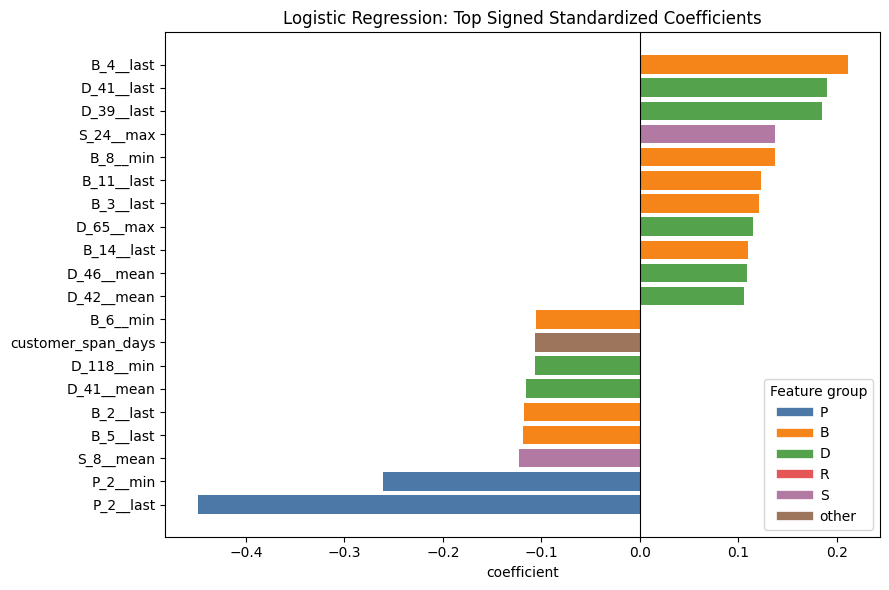

,feature,coefficient,abs_coefficient,feature_group
0,P_2__last,-0.448878,0.448878,P
1,P_2__min,-0.260469,0.260469,P
2,B_4__last,0.210712,0.210712,B
3,D_41__last,0.189554,0.189554,D
4,D_39__last,0.184775,0.184775,D
5,S_24__max,0.137600,0.137600,S
6,B_8__min,0.136705,0.136705,B
7,B_11__last,0.123373,0.123373,B
8,S_8__mean,-0.122836,0.122836,S
9,B_3__last,0.120721,0.120721,B


In [3]:
linear_model_name = 'regularized_lr' if 'regularized_lr' in models else 'logreg_l2'
lr = models[linear_model_name]
lr_clf = final_estimator(lr)
lr_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_clf.coef_[0],
})
lr_coef['abs_coefficient'] = lr_coef['coefficient'].abs()
lr_coef['feature_group'] = lr_coef['feature'].map(feature_group)
lr_coef = lr_coef.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
interpretation_tables['logistic_regression_coefficients'] = lr_coef
save_table(lr_coef, 'logistic_regression_coefficients')
group_tables.append(group_summary(lr_coef, 'coefficient', 'logistic_regression'))

plot_top_signed(lr_coef, 'coefficient', 'Logistic Regression: Top Signed Standardized Coefficients', 'logistic_regression_top_coefficients')
display(lr_coef.head(25))


## Linear SVM

The full-data SVM baseline is linear for memory reasons. Its coefficients define the separating
hyperplane margin, so the interpretation is similar to logistic regression: large positive values push
customers toward the default side of the margin, and large negative values push away from it. The
scores are margins, not calibrated probabilities.

saved ../reports/interpretability/linear_svm_coefficients.csv


saved ../reports/interpretability/linear_svm_top_coefficients.png


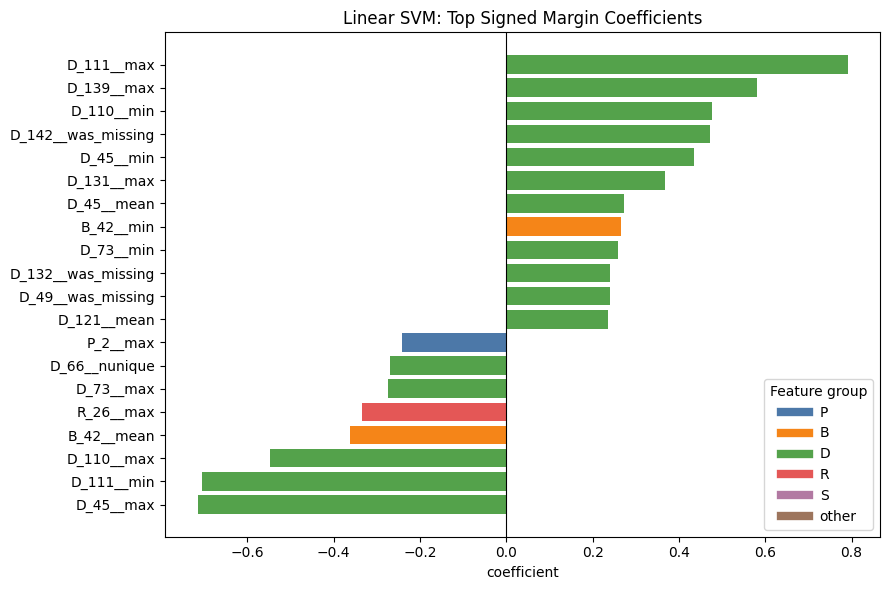

,feature,coefficient,abs_coefficient,feature_group
0,D_111__max,0.790585,0.790585,D
1,D_45__max,-0.715112,0.715112,D
2,D_111__min,-0.705549,0.705549,D
3,D_139__max,0.580867,0.580867,D
4,D_110__max,-0.547740,0.547740,D
5,D_110__min,0.475991,0.475991,D
6,D_142__was_missing,0.472451,0.472451,D
7,D_45__min,0.435418,0.435418,D
8,D_131__max,0.368624,0.368624,D
9,B_42__mean,-0.362162,0.362162,B


In [4]:
if 'linear_svm' in models:
    svm = models['linear_svm']
    svm_clf = final_estimator(svm)
    svm_coef = pd.DataFrame({'feature': X.columns, 'coefficient': svm_clf.coef_[0]})
    svm_coef['abs_coefficient'] = svm_coef['coefficient'].abs()
    svm_coef['feature_group'] = svm_coef['feature'].map(feature_group)
    svm_coef = svm_coef.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
    interpretation_tables['linear_svm_coefficients'] = svm_coef
    save_table(svm_coef, 'linear_svm_coefficients')
    group_tables.append(group_summary(svm_coef, 'coefficient', 'linear_svm'))
    plot_top_signed(svm_coef, 'coefficient', 'Linear SVM: Top Signed Margin Coefficients', 'linear_svm_top_coefficients')
    display(svm_coef.head(25))
else:
    print('linear_svm artifact not found.')


## Single Decision Tree

A single tree is less accurate than boosted trees, but it is the easiest tree-based model to explain.
The plot below shows the top levels of the fitted decision tree. Split nodes are color-coded by AMEX
feature group; leaf nodes are gray.

|--- P_2__last <= 0.53
|   |--- payment_to_balance <= 4.19
|   |   |--- R_1__last <= 0.50
|   |   |   |--- P_2__last <= 0.37
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- P_2__last >  0.37
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- R_1__last >  0.50
|   |   |   |--- D_39__max <= 0.91
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- D_39__max >  0.91
|   |   |   |   |--- truncated branch of depth 5
|   |--- payment_to_balance >  4.19
|   |   |--- D_44__last <= 0.13
|   |   |   |--- D_42__max <= 0.16
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- D_42__max >  0.16
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- D_44__last >  0.13
|   |   |   |--- P_2__last <= 0.38
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- P_2__last >  0.38
|   |   |   |   |--- truncated branch of depth 5
|--- P_2__last >  0.53
|   |--- payment_to_balance <= 3.97
|   |   |--- P_2__last <= 0.65
|   |   |   |--- 

saved ../reports/interpretability/decision_tree_structure_colored_by_group.png


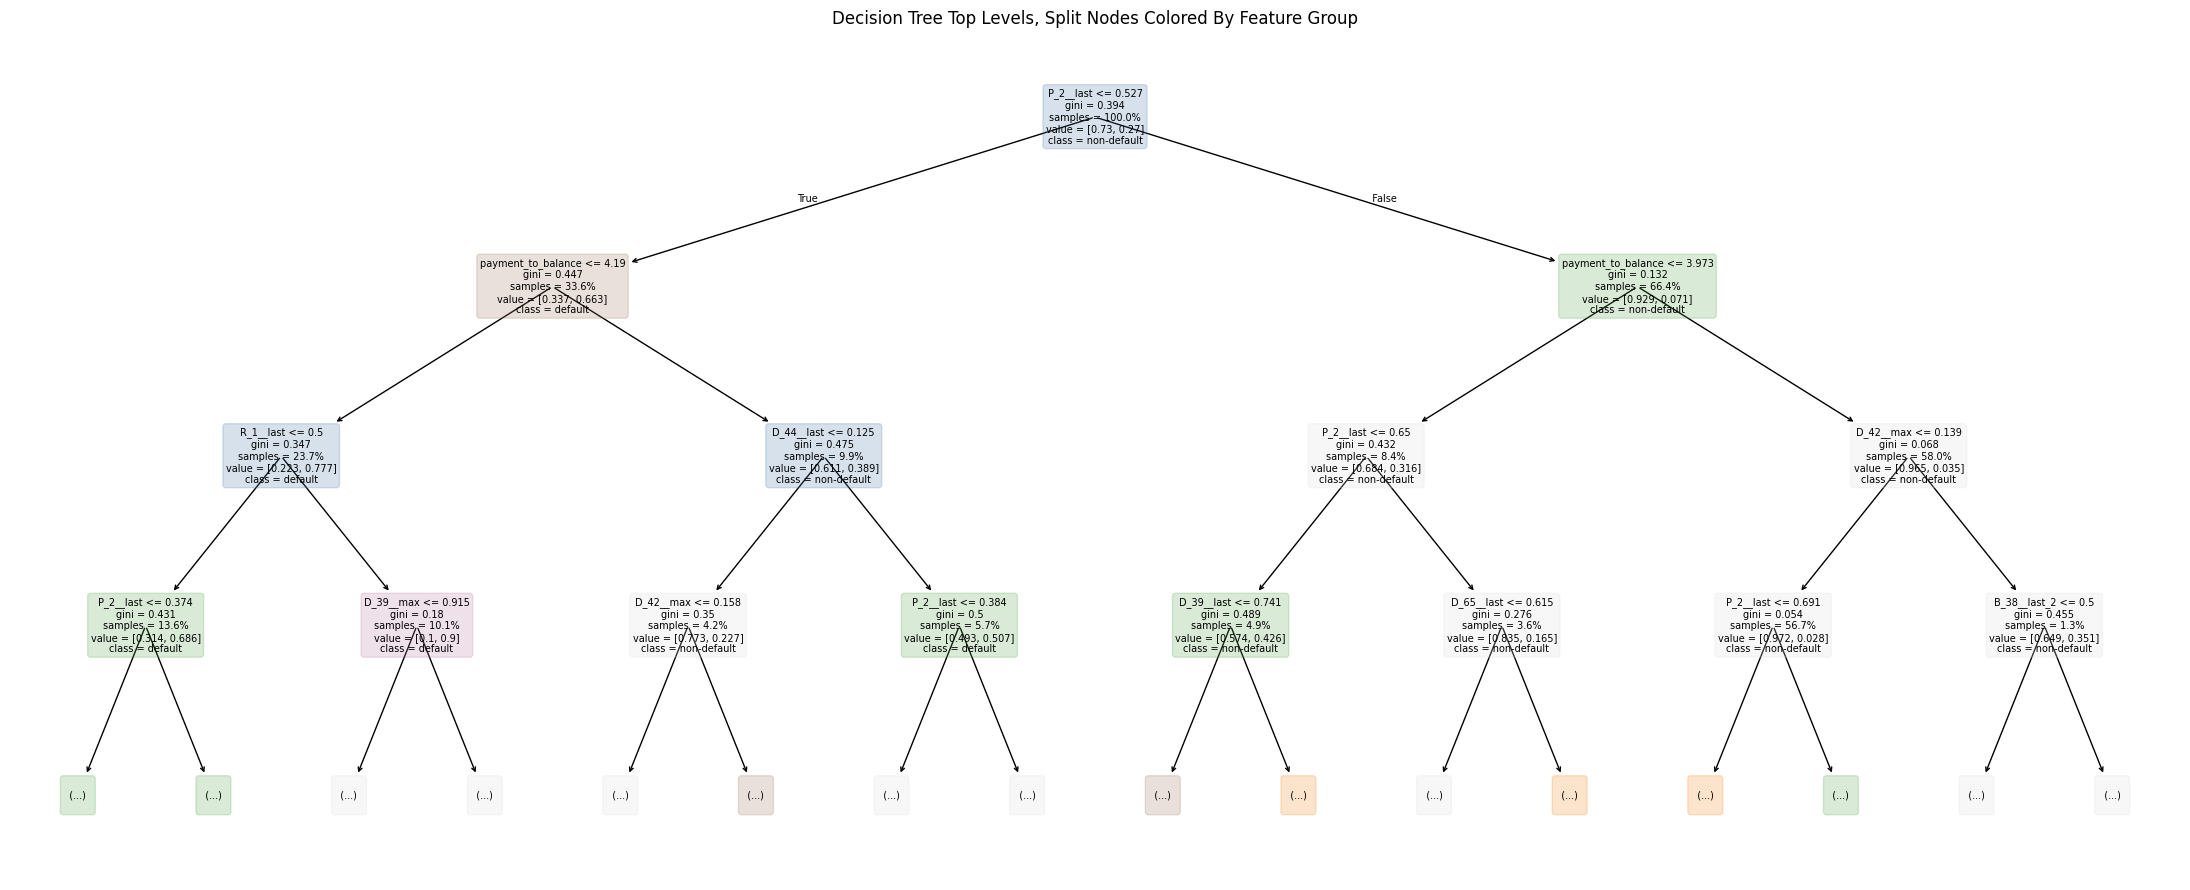

saved ../reports/interpretability/decision_tree_importance.csv
saved ../reports/interpretability/decision_tree_feature_importance.png


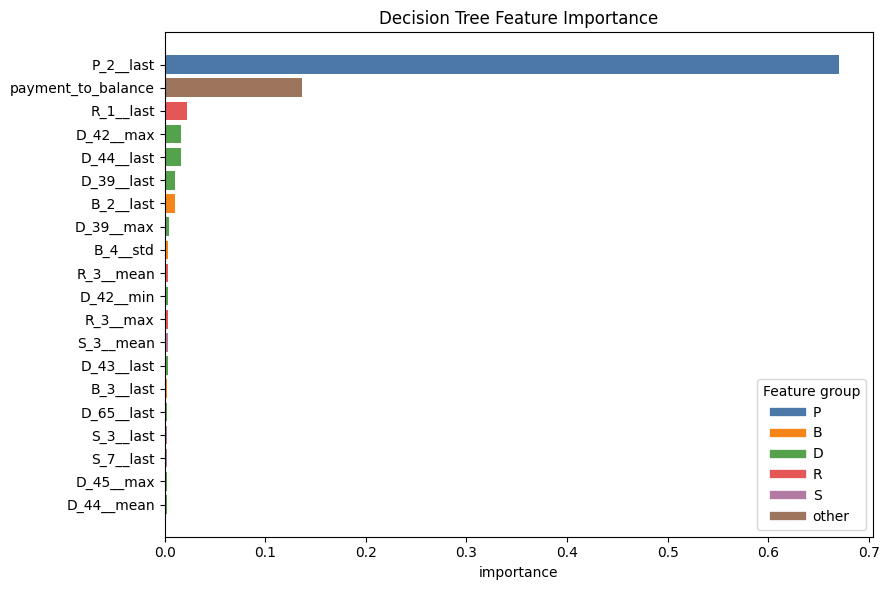

In [5]:
if 'decision_tree' in models:
    dt = models['decision_tree']
    dt_model = final_estimator(dt)
    tree_text = export_text(dt_model, feature_names=list(X.columns), max_depth=2)
    (REPORTS / 'decision_tree_top_levels.txt').write_text(tree_text)
    print(tree_text[:4000])

    # Presentation-friendly tree summary: the sklearn full tree is too dense to read on slides.
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
    fig, ax = plt.subplots(figsize=(16, 6.7))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    nodes = {
        'root': (0.50, 0.70, 0.28, 0.16, '#D7E4F2', 'P_2 last\n<= 0.53'),
        'left': (0.25, 0.30, 0.30, 0.16, '#EEEEEE', 'pay / balance\n<= 4.19'),
        'right': (0.75, 0.30, 0.30, 0.16, '#EEEEEE', 'pay / balance\n<= 3.97'),
    }
    for a, b, label in [('root', 'left', 'True'), ('root', 'right', 'False')]:
        x1, y1, *_ = nodes[a]
        x2, y2, *_ = nodes[b]
        ax.add_patch(FancyArrowPatch((x1, y1 - 0.085), (x2, y2 + 0.085), arrowstyle='-|>', mutation_scale=22, linewidth=2.6, color='#222222'))
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.055, label, ha='center', va='center', fontsize=28, color='#222222')
    for key, (x, y, w, h, color, split) in nodes.items():
        ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle='round,pad=0.012,rounding_size=0.016', linewidth=3, edgecolor='#222222', facecolor=color))
        ax.text(x, y, split, ha='center', va='center', fontsize=29, weight='bold', linespacing=0.90)
    ax.text(0.5, 0.93, 'Decision Tree: The First Two Splits', ha='center', va='center', fontsize=38, weight='bold')
    save_fig(fig, 'decision_tree_structure_colored_by_group')

    dt_imp = score_series(dt_model.feature_importances_, 'importance')
    interpretation_tables['decision_tree_importance'] = dt_imp
    save_table(dt_imp, 'decision_tree_importance')
    group_tables.append(group_summary(dt_imp, 'importance', 'decision_tree'))
    plot_top_positive(dt_imp, 'importance', 'Decision Tree Feature Importance', 'decision_tree_feature_importance')
else:
    print('decision_tree artifact not found.')


## Tree Ensembles

Tree ensembles are harder to explain as rules because predictions aggregate many trees. For random
forest, XGBoost, and LightGBM we summarize built-in split/importance scores where available. For
HistGradientBoosting, which does not expose the same feature-importance attribute, we use permutation
importance on a held-out sample.

saved ../reports/interpretability/random_forest_importance.csv


saved ../reports/interpretability/random_forest_feature_importance.png


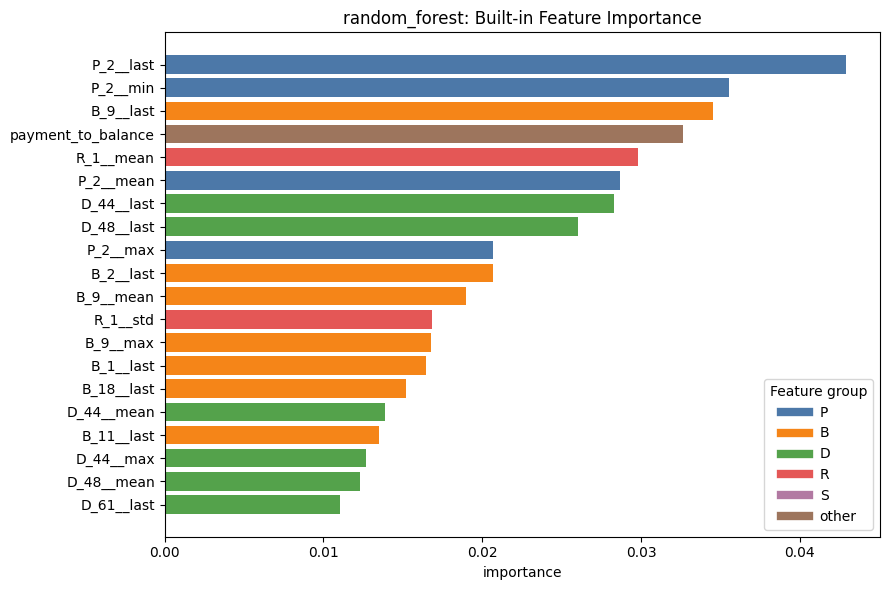

,feature,importance,abs_score,feature_group
0,P_2__last,0.042902,0.042902,P
1,P_2__min,0.035552,0.035552,P
2,B_9__last,0.034540,0.034540,B
3,payment_to_balance,0.032659,0.032659,payment
4,R_1__mean,0.029826,0.029826,R
5,P_2__mean,0.028666,0.028666,P
6,D_44__last,0.028285,0.028285,D
7,D_48__last,0.026053,0.026053,D
8,P_2__max,0.020702,0.020702,P
9,B_2__last,0.020686,0.020686,B


saved ../reports/interpretability/xgboost_importance.csv
saved ../reports/interpretability/xgboost_feature_importance.png


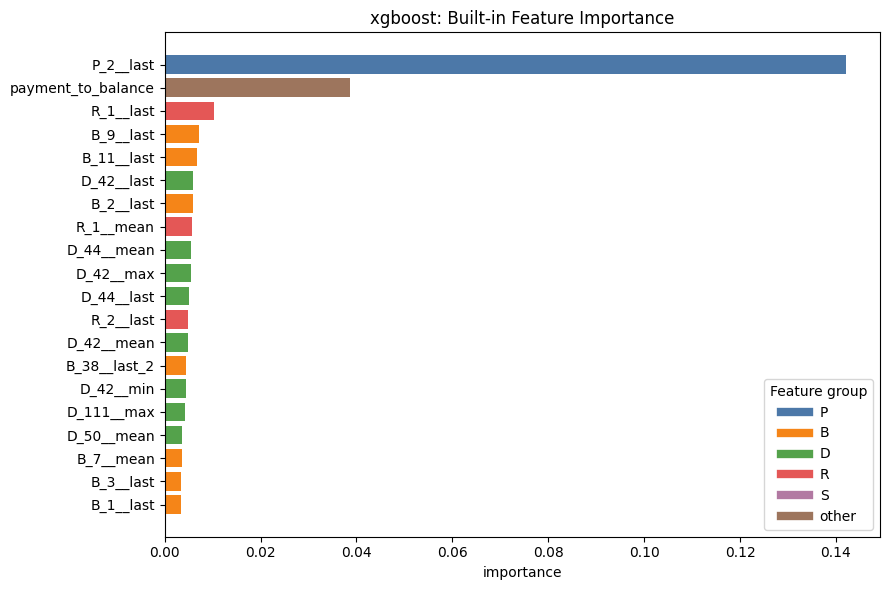

,feature,importance,abs_score,feature_group
0,P_2__last,0.142080,0.142080,P
1,payment_to_balance,0.038639,0.038639,payment
2,R_1__last,0.010293,0.010293,R
3,B_9__last,0.007135,0.007135,B
4,B_11__last,0.006659,0.006659,B
5,D_42__last,0.005889,0.005889,D
6,B_2__last,0.005857,0.005857,B
7,R_1__mean,0.005765,0.005765,R
8,D_44__mean,0.005525,0.005525,D
9,D_42__max,0.005521,0.005521,D


saved ../reports/interpretability/lgbm_tuned_importance.csv


saved ../reports/interpretability/lgbm_tuned_feature_importance.png


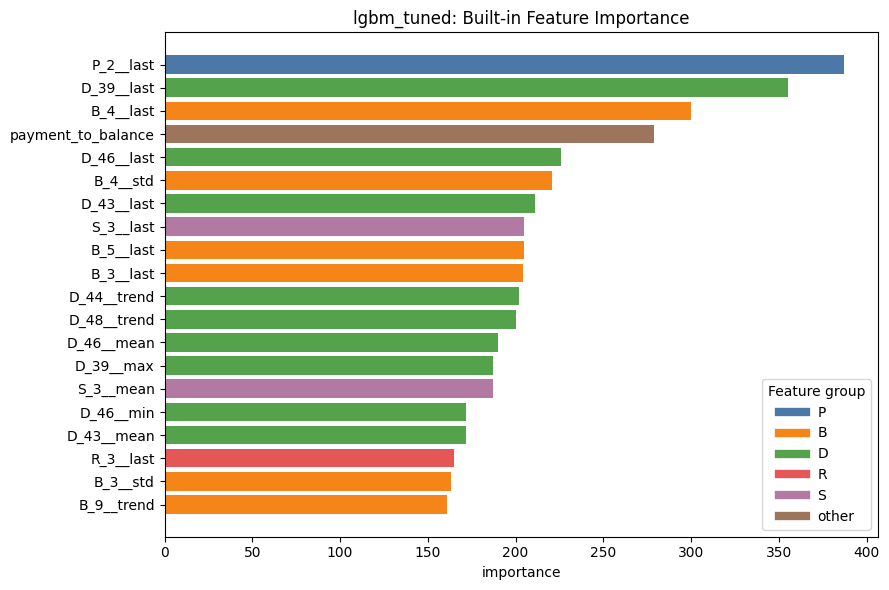

,feature,importance,abs_score,feature_group
0,P_2__last,387.0,387.0,P
1,D_39__last,355.0,355.0,D
2,B_4__last,300.0,300.0,B
3,payment_to_balance,279.0,279.0,payment
4,D_46__last,226.0,226.0,D
5,B_4__std,221.0,221.0,B
6,D_43__last,211.0,211.0,D
7,B_5__last,205.0,205.0,B
8,S_3__last,205.0,205.0,S
9,B_3__last,204.0,204.0,B


In [6]:
tree_importance_models = ['random_forest', 'xgboost', 'lgbm_tuned']
for name in tree_importance_models:
    if name not in models:
        print(f'{name} artifact not found; skipping.')
        continue
    estimator = final_estimator(models[name])
    if not hasattr(estimator, 'feature_importances_'):
        print(f'{name} has no feature_importances_; skipping built-in importance.')
        continue
    imp = score_series(estimator.feature_importances_, 'importance')
    interpretation_tables[f'{name}_importance'] = imp
    save_table(imp, f'{name}_importance')
    group_tables.append(group_summary(imp, 'importance', name))
    plot_top_positive(imp, 'importance', f'{name}: Built-in Feature Importance', f'{name}_feature_importance')
    display(imp.head(15))


## Permutation Importance For Harder Models

Permutation importance asks: how much does validation ROC-AUC fall when one feature is randomly
shuffled? This is slower than coefficient or split importance, so it runs on a controlled evaluation
sample. It works for models whose internal mechanics are less directly interpretable, including
HistGB, MLP, and the linear SVM.

permutation importance for histgb on 5,000 rows...


saved ../reports/interpretability/histgb_permutation_importance.csv
saved ../reports/interpretability/histgb_permutation_importance.png


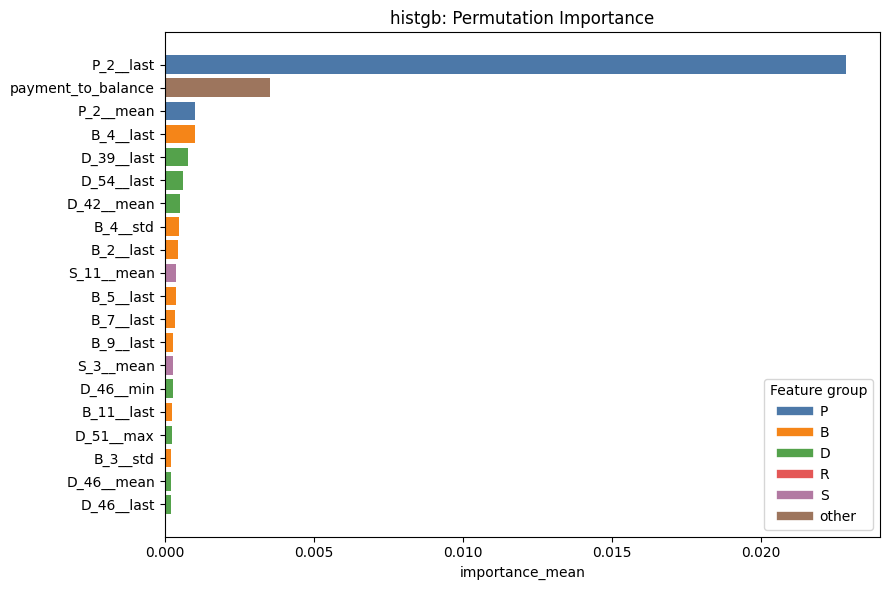

,feature,importance_mean,importance_std,feature_group
0,P_2__last,0.022843,0.000898,P
1,payment_to_balance,0.003540,0.000159,payment
2,P_2__mean,0.001028,0.000268,P
3,B_4__last,0.001016,0.000071,B
4,D_39__last,0.000790,0.000153,D
5,D_54__last,0.000623,0.000044,D
6,D_42__mean,0.000500,0.000046,D
7,B_4__std,0.000470,0.000108,B
8,B_2__last,0.000439,0.000186,B
9,S_11__mean,0.000373,0.000050,S


permutation importance for linear_svm on 5,000 rows...


saved ../reports/interpretability/linear_svm_permutation_importance.csv
saved ../reports/interpretability/linear_svm_permutation_importance.png


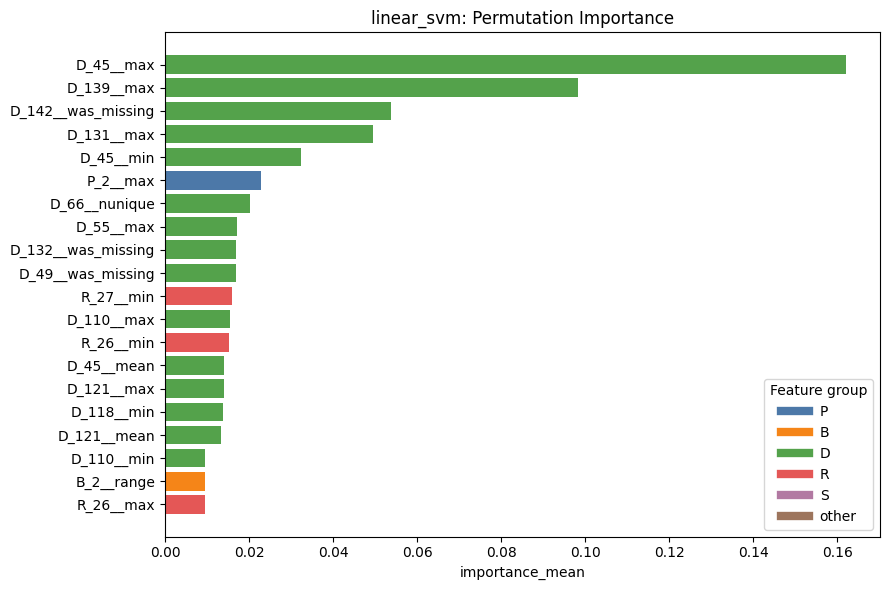

,feature,importance_mean,importance_std,feature_group
0,D_45__max,0.162033,0.004039,D
1,D_139__max,0.098157,0.004020,D
2,D_142__was_missing,0.053698,0.003540,D
3,D_131__max,0.049482,0.000215,D
4,D_45__min,0.032314,0.001196,D
5,P_2__max,0.022805,0.000290,P
6,D_66__nunique,0.020281,0.002135,D
7,D_55__max,0.017043,0.000317,D
8,D_132__was_missing,0.016911,0.000232,D
9,D_49__was_missing,0.016911,0.000232,D


permutation importance for mlp on 5,000 rows...


saved ../reports/interpretability/mlp_permutation_importance.csv
saved ../reports/interpretability/mlp_permutation_importance.png


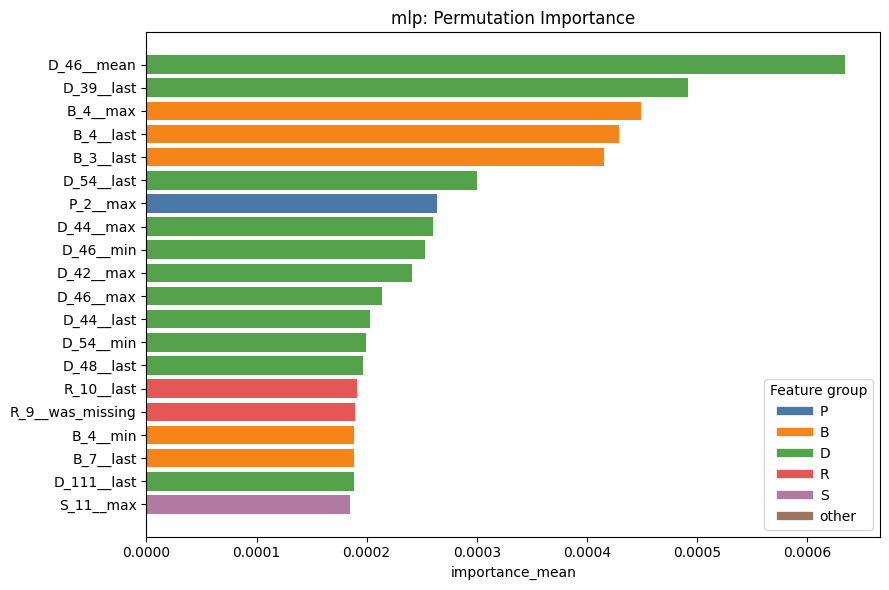

,feature,importance_mean,importance_std,feature_group
0,D_46__mean,0.000635,0.000047,D
1,D_39__last,0.000492,0.000091,D
2,B_4__max,0.000449,0.000027,B
3,B_4__last,0.000429,0.000041,B
4,B_3__last,0.000416,0.000109,B
5,D_54__last,0.000300,0.000054,D
6,P_2__max,0.000264,0.000039,P
7,D_44__max,0.000261,0.000003,D
8,D_46__min,0.000253,0.000071,D
9,D_42__max,0.000241,0.000041,D


In [7]:
permutation_model_names = [name for name in ['histgb', 'linear_svm', 'mlp'] if name in models]
for name in permutation_model_names:
    print(f'permutation importance for {name} on {len(X_perm):,} rows...')
    result = permutation_importance(
        models[name],
        X_perm,
        y_perm,
        scoring='roc_auc',
        n_repeats=PERMUTATION_REPEATS,
        random_state=SEED,
        n_jobs=1,
    )
    perm = pd.DataFrame({
        'feature': X.columns,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
    })
    perm['feature_group'] = perm['feature'].map(feature_group)
    perm = perm.sort_values('importance_mean', ascending=False).reset_index(drop=True)
    interpretation_tables[f'{name}_permutation_importance'] = perm
    save_table(perm, f'{name}_permutation_importance')
    group_tables.append(group_summary(perm, 'importance_mean', f'{name}_permutation'))
    plot_top_positive(perm, 'importance_mean', f'{name}: Permutation Importance', f'{name}_permutation_importance')
    display(perm.head(15))


## MLP Approximation

The MLP is not naturally transparent. We use two approximate views:

1. **Permutation importance** above, which measures predictive dependence on each feature.
2. **First-layer input weight strength** below, which shows which standardized inputs have the
   largest direct connections into the hidden layer. This is not causal and not a final feature
   importance measure, but it is a useful sanity check.

saved ../reports/interpretability/mlp_first_layer_weights.csv
saved ../reports/interpretability/mlp_first_layer_weights.png


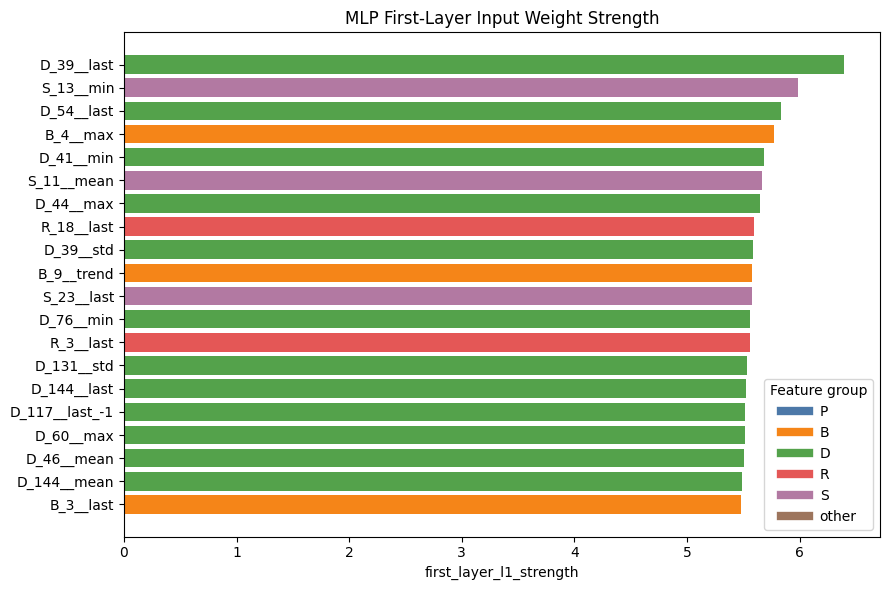

,feature,first_layer_l1_strength,feature_group
0,D_39__last,6.392492,D
1,S_13__min,5.985134,S
2,D_54__last,5.831137,D
3,B_4__max,5.767628,B
4,D_41__min,5.685410,D
5,S_11__mean,5.661563,S
6,D_44__max,5.646771,D
7,R_18__last,5.596180,R
8,D_39__std,5.580844,D
9,B_9__trend,5.578912,B


In [8]:
if 'mlp' in models:
    mlp = models['mlp']
    mlp_model = final_estimator(mlp)
    first_layer = mlp_model.coefs_[0]
    strength = np.linalg.norm(first_layer, ord=1, axis=1)
    mlp_weights = pd.DataFrame({'feature': X.columns, 'first_layer_l1_strength': strength})
    mlp_weights['feature_group'] = mlp_weights['feature'].map(feature_group)
    mlp_weights = mlp_weights.sort_values('first_layer_l1_strength', ascending=False).reset_index(drop=True)
    interpretation_tables['mlp_first_layer_weights'] = mlp_weights
    save_table(mlp_weights, 'mlp_first_layer_weights')
    group_tables.append(group_summary(mlp_weights, 'first_layer_l1_strength', 'mlp_first_layer'))
    plot_top_positive(mlp_weights, 'first_layer_l1_strength', 'MLP First-Layer Input Weight Strength', 'mlp_first_layer_weights')
    display(mlp_weights.head(25))
else:
    print('mlp artifact not found.')


## Generative Baselines

Gaussian Naive Bayes and LDA are not expected to win here, but they give simple sanity-check views.
For GaussianNB, we compare class-conditional means after the pipeline's imputation/scaling. For LDA,
we use its linear coefficients.

saved ../reports/interpretability/gaussian_nb_class_mean_delta.csv
saved ../reports/interpretability/gaussian_nb_class_mean_delta.png


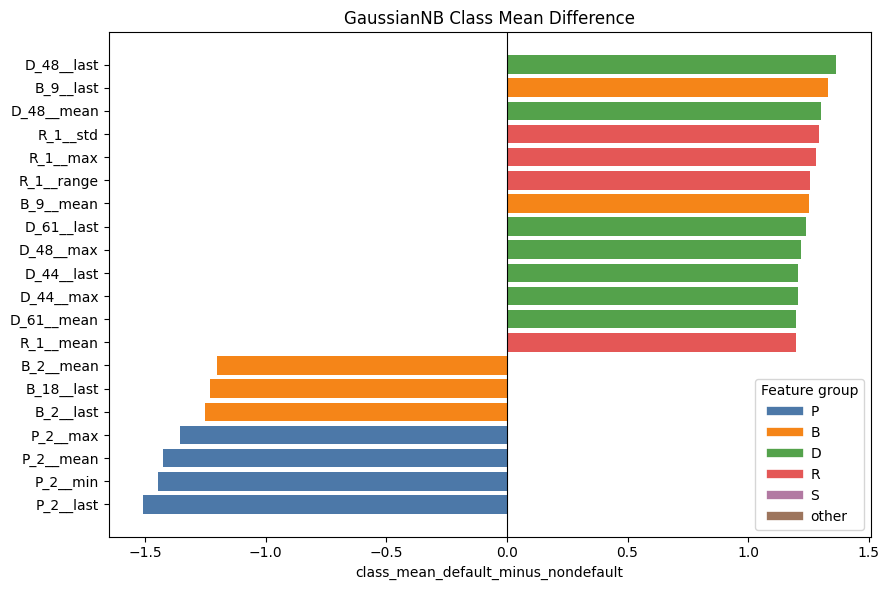

,feature,class_mean_default_minus_nondefault,feature_group,abs_score
0,P_2__last,-1.507009,P,1.507009
1,P_2__min,-1.444041,P,1.444041
2,P_2__mean,-1.426529,P,1.426529
3,D_48__last,1.363591,D,1.363591
4,P_2__max,-1.353345,P,1.353345
5,B_9__last,1.328992,B,1.328992
6,D_48__mean,1.301129,D,1.301129
7,R_1__std,1.291659,R,1.291659
8,R_1__max,1.282738,R,1.282738
9,R_1__range,1.254544,R,1.254544


saved ../reports/interpretability/lda_coefficients.csv
saved ../reports/interpretability/lda_top_coefficients.png


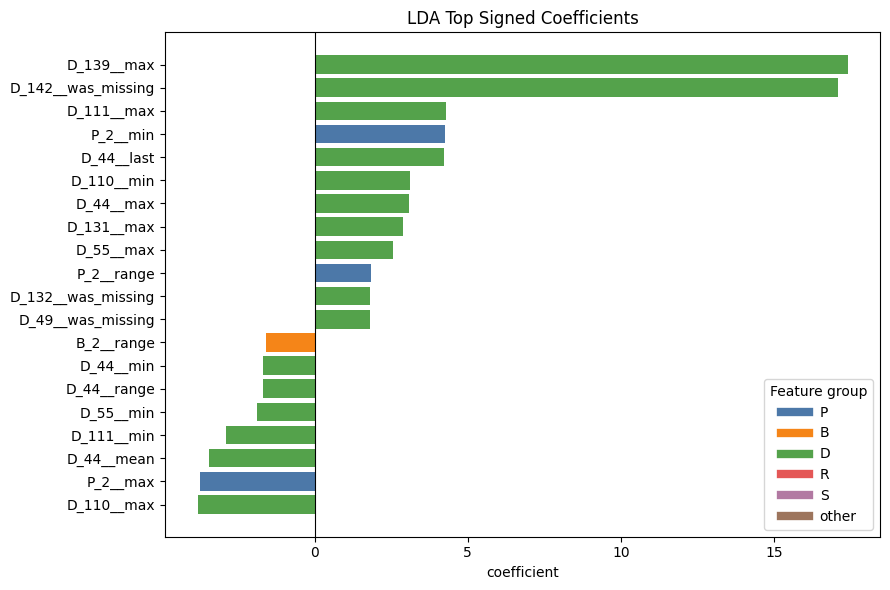

,feature,coefficient,feature_group,abs_coefficient
0,D_139__max,17.401129,D,17.401129
1,D_142__was_missing,17.093314,D,17.093314
2,D_111__max,4.283872,D,4.283872
3,P_2__min,4.244495,P,4.244495
4,D_44__last,4.228539,D,4.228539
5,D_110__max,-3.820471,D,3.820471
6,P_2__max,-3.743507,P,3.743507
7,D_44__mean,-3.443002,D,3.443002
8,D_110__min,3.120655,D,3.120655
9,D_44__max,3.096996,D,3.096996


In [9]:
if 'gaussian_nb' in models:
    nb_model = final_estimator(models['gaussian_nb'])
    if hasattr(nb_model, 'theta_') and nb_model.theta_.shape[0] == 2:
        nb_delta = pd.DataFrame({'feature': X.columns, 'class_mean_default_minus_nondefault': nb_model.theta_[1] - nb_model.theta_[0]})
        nb_delta['feature_group'] = nb_delta['feature'].map(feature_group)
        nb_delta['abs_score'] = nb_delta['class_mean_default_minus_nondefault'].abs()
        nb_delta = nb_delta.sort_values('abs_score', ascending=False).reset_index(drop=True)
        interpretation_tables['gaussian_nb_class_mean_delta'] = nb_delta
        save_table(nb_delta, 'gaussian_nb_class_mean_delta')
        group_tables.append(group_summary(nb_delta, 'class_mean_default_minus_nondefault', 'gaussian_nb'))
        plot_top_signed(nb_delta, 'class_mean_default_minus_nondefault', 'GaussianNB Class Mean Difference', 'gaussian_nb_class_mean_delta')
        display(nb_delta.head(15))

if 'lda' in models:
    lda_model = final_estimator(models['lda'])
    lda_coef = pd.DataFrame({'feature': X.columns, 'coefficient': lda_model.coef_[0]})
    lda_coef['feature_group'] = lda_coef['feature'].map(feature_group)
    lda_coef['abs_coefficient'] = lda_coef['coefficient'].abs()
    lda_coef = lda_coef.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
    interpretation_tables['lda_coefficients'] = lda_coef
    save_table(lda_coef, 'lda_coefficients')
    group_tables.append(group_summary(lda_coef, 'coefficient', 'lda'))
    plot_top_signed(lda_coef, 'coefficient', 'LDA Top Signed Coefficients', 'lda_top_coefficients')
    display(lda_coef.head(15))


## Cross-Model Synthesis

This section compares the broad AMEX feature groups that different model families rely on. Scores are
normalized within each model-specific interpretation table before aggregating, so the chart compares
relative emphasis rather than raw coefficient/importance scales.

saved ../reports/interpretability/feature_group_importance_summary.csv


,feature_group,total_abs_score,model,share
20,P,0.672392,decision_tree,0.672392
21,payment,0.136913,decision_tree,0.136913
22,D,0.094744,decision_tree,0.094744
23,R,0.038730,decision_tree,0.038730
24,B,0.037898,decision_tree,0.037898
...,...,...,...,...
45,payment,0.038639,xgboost,0.038639
46,customer,0.000620,xgboost,0.000620
47,spend,0.000600,xgboost,0.000600
48,missing,0.000595,xgboost,0.000595


saved ../reports/interpretability/feature_group_importance_heatmap.png


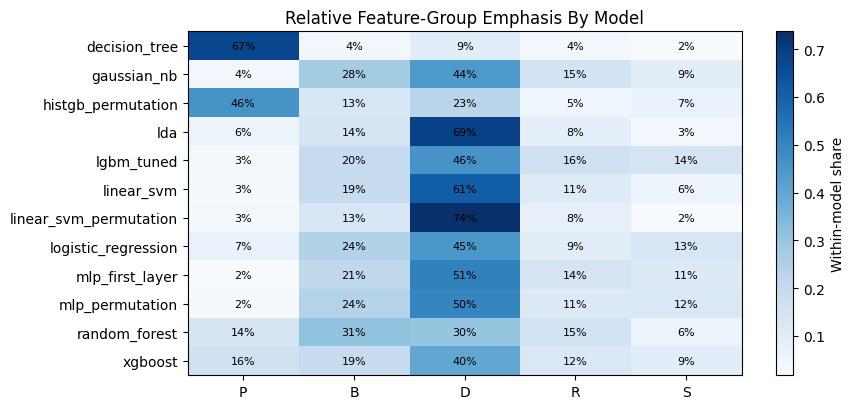

In [10]:
if group_tables:
    group_summary_all = pd.concat(group_tables, ignore_index=True)
    save_table(group_summary_all, 'feature_group_importance_summary')
    display(group_summary_all.sort_values(['model', 'share'], ascending=[True, False]))

    pivot = group_summary_all.pivot_table(index='model', columns='feature_group', values='share', fill_value=0)
    ordered_cols = [c for c in ['P', 'B', 'D', 'R', 'S', 'other'] if c in pivot.columns]
    pivot = pivot[ordered_cols]
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(pivot))))
    im = ax.imshow(pivot.values, aspect='auto', cmap='Blues')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title('Relative Feature-Group Emphasis By Model')
    fig.colorbar(im, ax=ax, label='Within-model share')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f'{pivot.iloc[i, j]:.0%}', ha='center', va='center', fontsize=8)
    save_fig(fig, 'feature_group_importance_heatmap')
else:
    print('No group summaries were produced.')


In [1]:
# Export a rendered copy of this finished notebook.
from pathlib import Path
import subprocess
import sys

if Path('06_interpretability.ipynb').exists():
    notebook_path = Path('06_interpretability.ipynb')
    output_dir = Path('../reports/interpretability')
elif Path('notebooks/06_interpretability.ipynb').exists():
    notebook_path = Path('notebooks/06_interpretability.ipynb')
    output_dir = Path('reports/interpretability')
else:
    raise FileNotFoundError('Could not find 06_interpretability.ipynb from the current working directory.')

output_dir.mkdir(parents=True, exist_ok=True)
output_name = '06_interpretability_finished'

subprocess.run(
    [
        sys.executable, '-m', 'jupyter', 'nbconvert',
        '--to', 'html',
        '--output', output_name,
        '--output-dir', str(output_dir),
        str(notebook_path),
    ],
    check=True,
)

print(f'saved rendered notebook to {output_dir / (output_name + ".html")}')


[NbConvertApp] Converting notebook 06_interpretability.ipynb to html


saved rendered notebook to ../reports/interpretability/06_interpretability_finished.html


[NbConvertApp] WARNING | Alternative text is missing on 14 image(s).
[NbConvertApp] Writing 1311417 bytes to ../reports/interpretability/06_interpretability_finished.html
